In [110]:
import pandas as pd
import os

# --- paths ---
base_dir = "../results/casecontrol_by_age_results_2"
age_dirs = ["age-21", "age-60"]

all_dfs = []

for age_dir in age_dirs:
    folder = os.path.join(base_dir, age_dir)
    if not os.path.exists(folder):
        print(f"⚠️ Folder not found: {folder}")
        continue

    files = [f for f in os.listdir(folder) if f.endswith(".csv")]
    print(f"📂 Reading {len(files)} files from {age_dir}...")

    for f in files:
        file_path = os.path.join(folder, f)
        try:
            df = pd.read_csv(file_path)
            # ensure consistent age field
            if "age" not in df.columns:
                df["age"] = age_dir.replace("age-", "")
            df["source_file"] = f
            all_dfs.append(df)
        except Exception as e:
            print(f"  ❌ Error reading {file_path}: {e}")

# --- combine into one dataframe ---
if all_dfs:
    combined_df = pd.concat(all_dfs, ignore_index=True)
    print(f"\n✅ Combined total rows: {combined_df.shape[0]}")
else:
    combined_df = pd.DataFrame()
    print("⚠️ No files read.")

# --- optional: save combined file ---
out_path = os.path.join(base_dir, "casecontrol_combined_from_folders.csv")
combined_df.to_csv(out_path, index=False)
print(f"💾 Saved combined results → {out_path}")

📂 Reading 146 files from age-21...
📂 Reading 146 files from age-60...

✅ Combined total rows: 3504
💾 Saved combined results → ../results/casecontrol_by_age_results_2/casecontrol_combined_from_folders.csv


In [111]:
combined_df

,group,posterior_mean,posterior_sd,p(>0),p(<0),PEP,qvalue,selected_fdr_0.05,feature,age,source_file
0,Oligodendrocyte Precursor Cells,0.013472,0.011653,0.877,0.123,0.123,0.123000,False,Serpina3n,21,Serpina3n_casecontrol.csv
1,Medium Spiny Neurons,-0.012675,0.012358,0.147,0.853,0.147,0.135000,False,Serpina3n,21,Serpina3n_casecontrol.csv
2,Neurons,0.011966,0.014145,0.800,0.200,0.200,0.156667,False,Serpina3n,21,Serpina3n_casecontrol.csv
3,Oligodendrocytes,0.005432,0.010672,0.697,0.303,0.303,0.193250,False,Serpina3n,21,Serpina3n_casecontrol.csv
4,Myocytes,0.013419,0.024683,0.696,0.304,0.304,0.215400,False,Serpina3n,21,Serpina3n_casecontrol.csv
...,...,...,...,...,...,...,...,...,...,...,...
3499,Microglia,-0.003402,0.017733,0.420,0.580,0.420,0.205375,False,Tgfbr3,60,Tgfbr3_casecontrol.csv
3500,Astrocytes,0.001650,0.017086,0.556,0.444,0.444,0.231889,False,Tgfbr3,60,Tgfbr3_casecontrol.csv
3501,Endothelial Cells,-0.002357,0.029826,0.471,0.529,0.471,0.255800,False,Tgfbr3,60,Tgfbr3_casecontrol.csv
3502,Neural Stem Cells,0.001426,0.020464,0.529,0.471,0.471,0.275364,False,Tgfbr3,60,Tgfbr3_casecontrol.csv


In [115]:
ol = combined_df[combined_df.group == 'Oligodendrocytes']
#ol = ol[ol['selected_fdr_0.05']]
ol[ol.feature=='C4b']

,group,posterior_mean,posterior_sd,p(>0),p(<0),PEP,qvalue,selected_fdr_0.05,feature,age,source_file


In [60]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [72]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

def plot_bayesian_age_comparison(
    cc: pd.DataFrame,
    celltype: str = "Oligodendrocytes",
    age_x: str = "21",
    age_y: str = "60",
    top_n: int = 25,
    hue_clip=(-0.15, 0.15),
    figsize=(15, 8),
    force_genes=None,
    force_color="#111",
):
    """
    Scatter of posterior_mean at age_x vs age_y for a given cell type.
    Colors = Δ posterior_mean (age_y - age_x), Size = -log10(min q), Labels = top_n by |Δ|.
    'force_genes' are always labeled (no extra markers).
    """
    df = cc.copy()
    req_cols = ["group", "feature", "posterior_mean", "qvalue", "age"]
    missing_cols = [c for c in req_cols if c not in df.columns]
    if missing_cols:
        raise ValueError(f"Missing columns in cc: {missing_cols}")

    df["age"] = df["age"].astype(str)
    age_x = str(age_x)
    age_y = str(age_y)

    df = df[df["group"] == celltype].copy()
    if df.empty:
        raise ValueError(f"No rows for cell type '{celltype}'.")

    df["posterior_mean"] = pd.to_numeric(df["posterior_mean"], errors="coerce")
    df["qvalue"] = pd.to_numeric(df["qvalue"], errors="coerce")
    df = df.replace([np.inf, -np.inf], np.nan).dropna(subset=["posterior_mean", "qvalue", "age"])

    # pivot posterior means across ages
    pm = df.pivot_table(index="feature", columns="age", values="posterior_mean", aggfunc="mean")
    for a in (age_x, age_y):
        if a not in pm.columns:
            raise ValueError(f"Age '{a}' not present for '{celltype}'. Found: {sorted(pm.columns.tolist())}")

    comp = pm[[age_x, age_y]].rename(columns={age_x: "pm_x", age_y: "pm_y"}).dropna()

    # size by min q across ages
    qtab = df.pivot_table(index="feature", columns="age", values="qvalue", aggfunc="min")
    q_min = qtab.min(axis=1).reindex(comp.index)
    comp["neglogq"] = -np.log10(np.clip(q_min.values, 1e-10, 1.0))
    comp["delta"] = comp["pm_y"] - comp["pm_x"]

    # labeling
    top_auto = comp["delta"].abs().sort_values(ascending=False).head(top_n).index
    force_genes = [] if force_genes is None else list(force_genes)
    present_force = [g for g in force_genes if g in comp.index]
    missing_force = sorted(set(force_genes) - set(present_force))
    if missing_force:
        print(f"⚠️ Missing forced genes: {missing_force}")
    label_set = pd.Index(sorted(set(top_auto).union(present_force)))
    comp["label"] = np.where(comp.index.isin(label_set), comp.index, "")

    # plot
    sns.set(style="whitegrid", context="talk")
    plt.figure(figsize=figsize)
    ax = sns.scatterplot(
        data=comp,
        x="pm_x", y="pm_y",
        hue=np.clip(comp["delta"], *hue_clip),
        size="neglogq",
        palette="coolwarm",
        sizes=(40, 400),
        edgecolor="white",
        linewidth=0.6,
        alpha=0.9,
        legend=True
    )

    # guides
    lim_min = float(np.nanmin([comp["pm_x"].min(), comp["pm_y"].min()])) - 0.02
    lim_max = float(np.nanmax([comp["pm_x"].max(), comp["pm_y"].max()])) + 0.02
    ax.plot([lim_min, lim_max], [lim_min, lim_max], ":", color="black", lw=1)
    ax.axhline(0, color="#666", ls="--", lw=1)
    ax.axvline(0, color="#666", ls="--", lw=1)
    ax.set_xlim(lim_min, lim_max)
    ax.set_ylim(lim_min, lim_max)

    # labels
    for gene, row in comp.loc[label_set].iterrows():
        color = force_color if gene in present_force else "#222"
        ax.text(row["pm_x"], row["pm_y"], gene, fontsize=9, color=color, ha="center", va="bottom")

    # colorbar
    norm = plt.Normalize(*hue_clip)
    sm = plt.cm.ScalarMappable(cmap="coolwarm", norm=norm)
    sm.set_array([])
    cbar = plt.colorbar(sm, ax=ax, pad=0.02, fraction=0.046, aspect=25, location="right")
    cbar.set_label(f"Δ posterior_mean ({age_y} − {age_x})", labelpad=10)

    # titles
    ax.set_title(f"{celltype}: posterior mean comparison ({age_x} vs {age_y})", weight="bold", pad=20)
    ax.set_xlabel(f"Posterior mean at age {age_x}")
    ax.set_ylabel(f"Posterior mean at age {age_y}")

    # separate size legend outside
    from matplotlib.lines import Line2D
    if comp["neglogq"].max() > 0:
        size_values = comp["neglogq"].quantile([0.25, 0.5, 0.75, 0.95]).round(1).unique()
        size_handles = [
            Line2D([], [], marker="o", linestyle="", 
                   markersize=np.sqrt(s * (400 - 40) / comp["neglogq"].max() + 40 / comp["neglogq"].max()),
                   color="#555", alpha=0.6)
            for s in size_values
        ]
        ax.legend(size_handles, [f"{s:.1f}" for s in size_values],
                  title="−log10(q)", bbox_to_anchor=(1.38, 1),
                  loc="upper left", frameon=False, fontsize=10, title_fontsize=11)

    sns.despine()
    plt.tight_layout(rect=[0, 0, 0.83, 1])
    plt.show()

In [78]:
force_genes = [
    # ISR / mitochondrial stress
    "Atf4", "Atf5", "Ddit4", "Gstp1", "Mt2", "H2-D1", "B2m", "Txnip",
    # Metabolic / glycolysis
    "Aldoa", "Ldha", "Qdpr", "Agpat4",
    # Myelin & differentiation
    "Mbp", "Mog", "Mag", "Mal", "Cldn11", "Ermn", "Nkx6-2", "Olig2", "Pllp",
    # Inflammatory / signaling
    "Il33", "Jun", "Selenop", "Erbin"
]

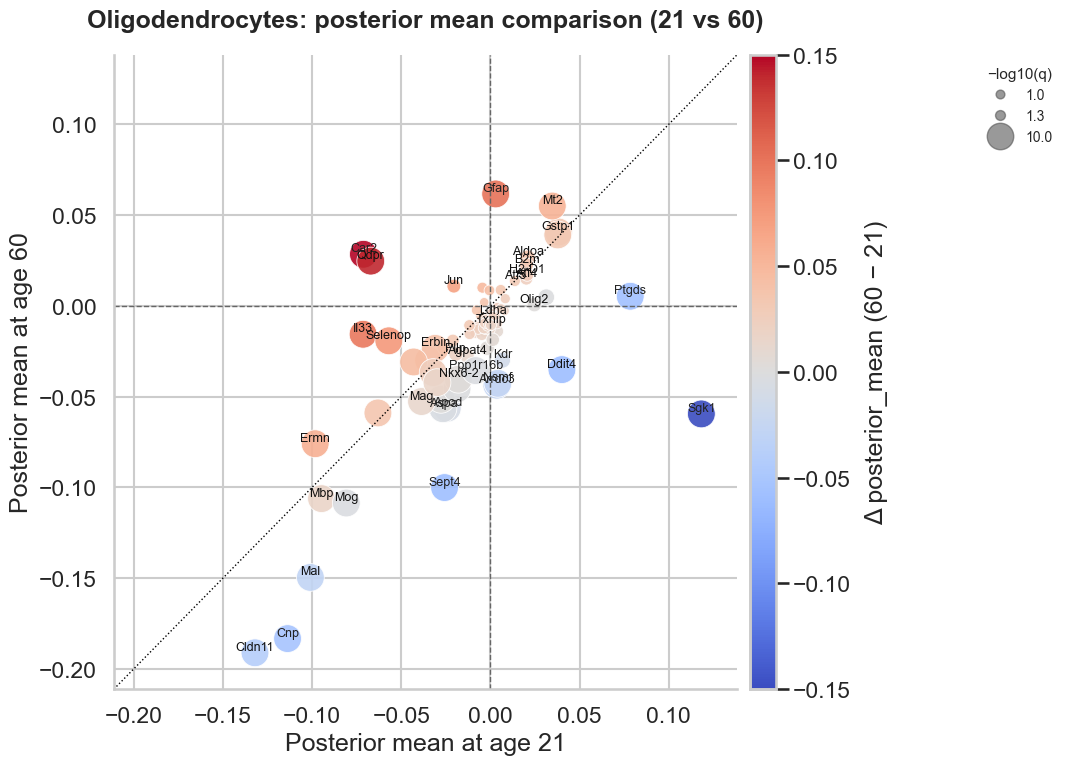

In [83]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

def plot_bayesian_age_comparison(
    cc: pd.DataFrame,
    celltype: str = "Oligodendrocytes",
    age_x: str = "21",
    age_y: str = "60",
    top_n: int = 25,
    hue_clip=(-0.15, 0.15),
    figsize=(15, 8),
    force_genes=None,            # always label these (if present)
    force_color="#111",
    remove_genes=None,           # remove these genes entirely from the plot
    remove_from_labels_only=False # if True: keep points, but never label these genes
):
    """
    Scatter of posterior_mean at age_x vs age_y for a given cell type.
    Color = Δ posterior_mean (age_y - age_x), Size = -log10(min q across ages).
    Labels = top_n by |Δ| plus any 'force_genes'.
    'remove_genes' lets you drop genes entirely OR just from labels.
    """
    df = cc.copy()
    req_cols = ["group", "feature", "posterior_mean", "qvalue", "age"]
    miss = [c for c in req_cols if c not in df.columns]
    if miss:
        raise ValueError(f"Missing columns in cc: {miss}")

    df["age"] = df["age"].astype(str)
    age_x, age_y = str(age_x), str(age_y)

    # subset to cell type
    df = df[df["group"] == celltype].copy()
    if df.empty:
        raise ValueError(f"No rows for cell type '{celltype}'.")

    # numeric clean
    df["posterior_mean"] = pd.to_numeric(df["posterior_mean"], errors="coerce")
    df["qvalue"] = pd.to_numeric(df["qvalue"], errors="coerce")
    df = df.replace([np.inf, -np.inf], np.nan).dropna(subset=["posterior_mean","qvalue","age"])

    # pivot posterior means across ages
    pm = df.pivot_table(index="feature", columns="age", values="posterior_mean", aggfunc="mean")
    for a in (age_x, age_y):
        if a not in pm.columns:
            raise ValueError(f"Age '{a}' not present for '{celltype}'. Found: {sorted(pm.columns.tolist())}")

    comp = pm[[age_x, age_y]].rename(columns={age_x:"pm_x", age_y:"pm_y"}).dropna()

    # size by min q across ages
    qtab = df.pivot_table(index="feature", columns="age", values="qvalue", aggfunc="min")
    q_min = qtab.min(axis=1).reindex(comp.index)
    comp["neglogq"] = -np.log10(np.clip(q_min.values, 1e-10, 1.0))
    comp["delta"] = comp["pm_y"] - comp["pm_x"]

    # --- handle removals ---
    remove_genes = [] if remove_genes is None else list(remove_genes)
    if not remove_from_labels_only and remove_genes:
        # drop these genes entirely
        comp = comp.drop(index=[g for g in remove_genes if g in comp.index], errors="ignore")

    # labeling set
    top_auto = comp["delta"].abs().sort_values(ascending=False).head(top_n).index
    force_genes = [] if force_genes is None else list(force_genes)
    present_force = [g for g in force_genes if g in comp.index]
    if force_genes and len(present_force) < len(force_genes):
        missing_force = sorted(set(force_genes) - set(present_force))
        print(f"⚠️ Missing forced genes: {missing_force}")

    label_candidates = set(top_auto).union(present_force)
    if remove_from_labels_only and remove_genes:
        # keep their points but never label them
        label_candidates = label_candidates - set(remove_genes)
    label_set = pd.Index(sorted(label_candidates))
    comp["label"] = np.where(comp.index.isin(label_set), comp.index, "")

    # plot
    sns.set(style="whitegrid", context="talk")
    plt.figure(figsize=figsize)
    ax = sns.scatterplot(
        data=comp,
        x="pm_x", y="pm_y",
        hue=np.clip(comp["delta"], *hue_clip),
        size="neglogq",
        palette="coolwarm",
        sizes=(40, 400),
        alpha=0.9,
        linewidth=0,        # no ring
        legend=True
    )

    # guides & limits
    lim_min = float(np.nanmin([comp["pm_x"].min(), comp["pm_y"].min()])) - 0.02
    lim_max = float(np.nanmax([comp["pm_x"].max(), comp["pm_y"].max()])) + 0.02
    ax.plot([lim_min, lim_max], [lim_min, lim_max], ":", color="black", lw=1)
    ax.axhline(0, color="#666", ls="--", lw=1)
    ax.axvline(0, color="#666", ls="--", lw=1)
    ax.set_xlim(lim_min, lim_max)
    ax.set_ylim(lim_min, lim_max)

    # labels
    for gene, row in comp.loc[label_set].iterrows():
        color = force_color if gene in present_force else "#222"
        ax.text(row["pm_x"], row["pm_y"], gene, fontsize=9, color=color, ha="center", va="bottom")

    # colorbar
    norm = plt.Normalize(*hue_clip)
    sm = plt.cm.ScalarMappable(cmap="coolwarm", norm=norm)
    sm.set_array([])
    cbar = plt.colorbar(sm, ax=ax, pad=0.02, fraction=0.046, aspect=25, location="right")
    cbar.set_label(f"Δ posterior_mean ({age_y} − {age_x})", labelpad=10)

    # titles
    ax.set_title(f"{celltype}: posterior mean comparison ({age_x} vs {age_y})", weight="bold", pad=20)
    ax.set_xlabel(f"Posterior mean at age {age_x}")
    ax.set_ylabel(f"Posterior mean at age {age_y}")

    # size legend outside
    from matplotlib.lines import Line2D
    if comp["neglogq"].max() > 0:
        size_values = comp["neglogq"].quantile([0.25, 0.5, 0.75, 0.95]).round(1).unique()
        scale = lambda s: np.interp(s, [comp["neglogq"].min(), comp["neglogq"].max()], [40, 400])**0.5
        size_handles = [Line2D([], [], marker="o", linestyle="", markersize=scale(s), color="#555", alpha=0.6)
                        for s in size_values]
        ax.legend(size_handles, [f"{s:.1f}" for s in size_values],
                  title="−log10(q)", bbox_to_anchor=(1.38, 1),
                  loc="upper left", frameon=False, fontsize=10, title_fontsize=11)

    sns.despine()
    plt.tight_layout(rect=[0, 0, 0.83, 1])
    plt.show()

In [ ]:
plot_bayesian_age_comparison(
    cc, celltype="Oligodendrocytes", age_x="21", age_y="60",
    force_genes=force_genes,
    remove_genes=["Xist"],              # gone from plot
    remove_from_labels_only=False
)

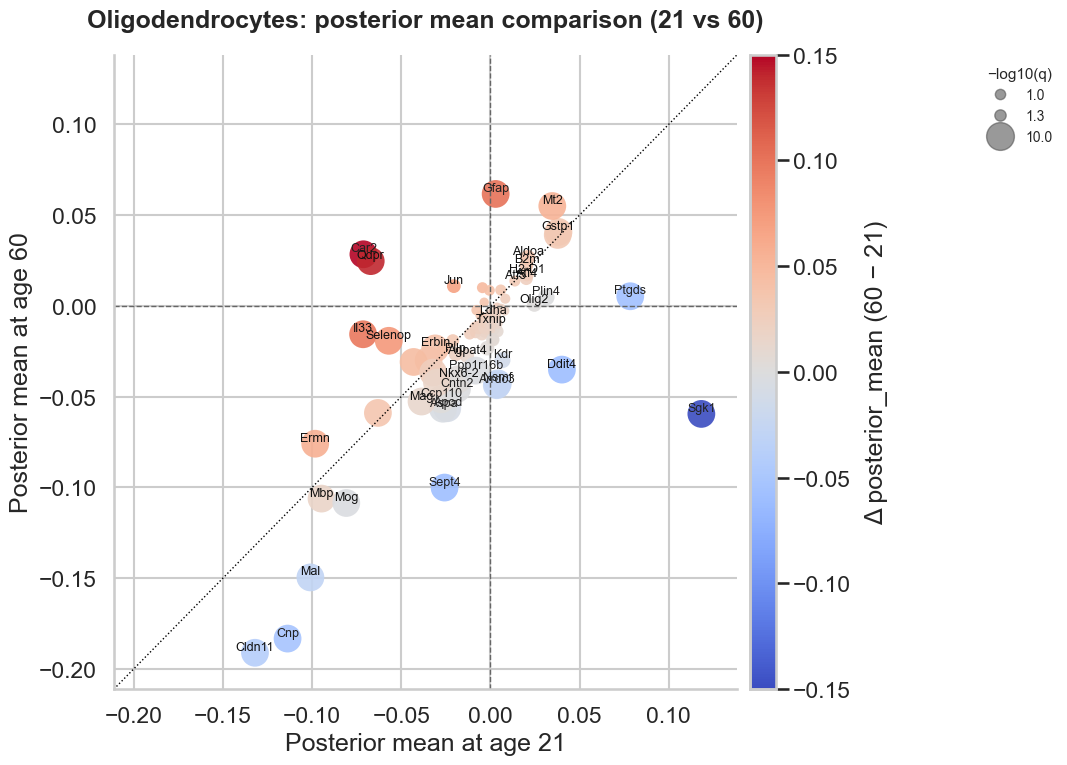

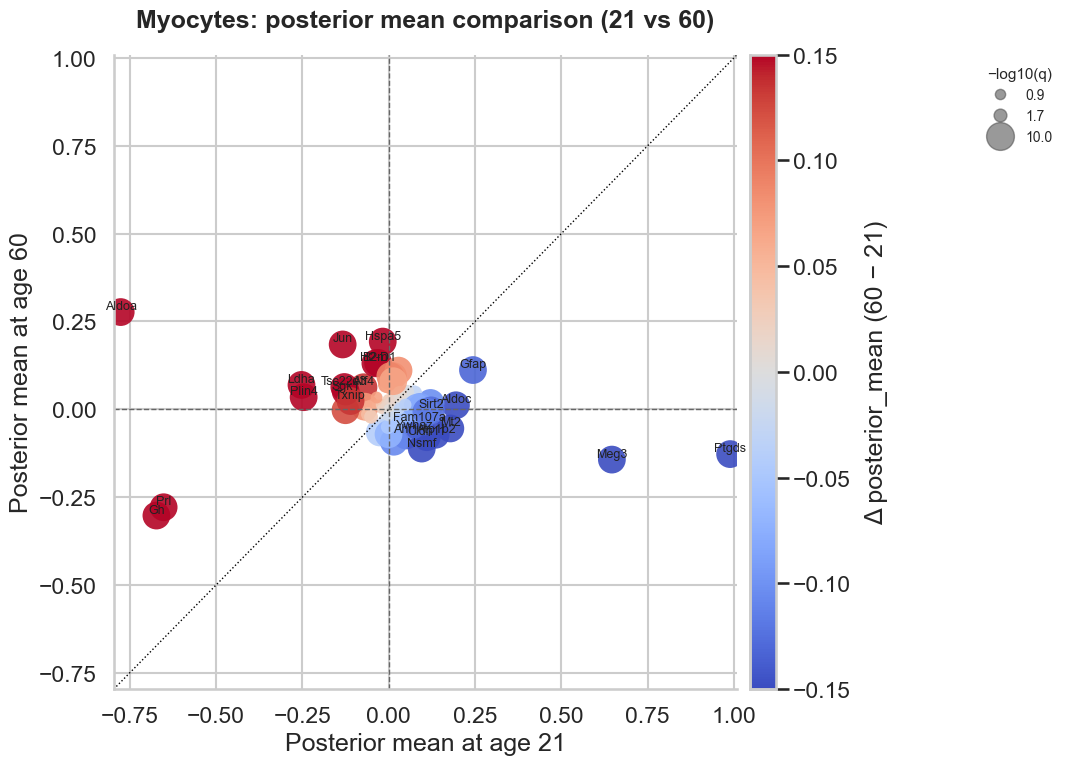

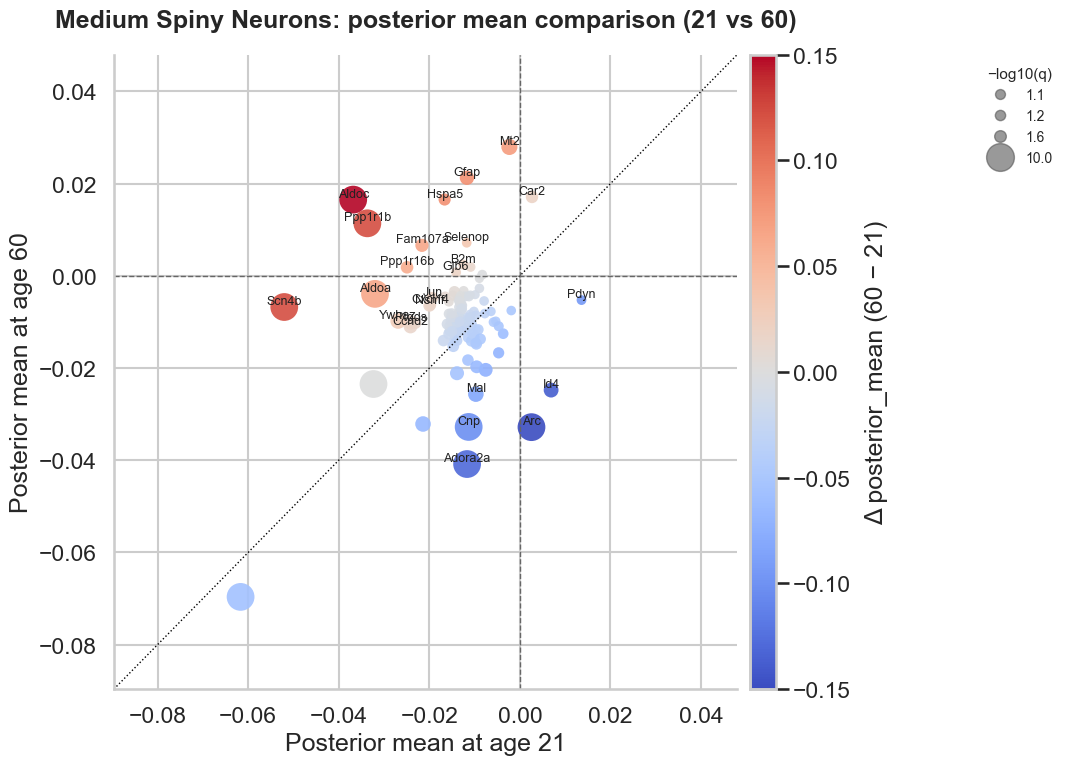

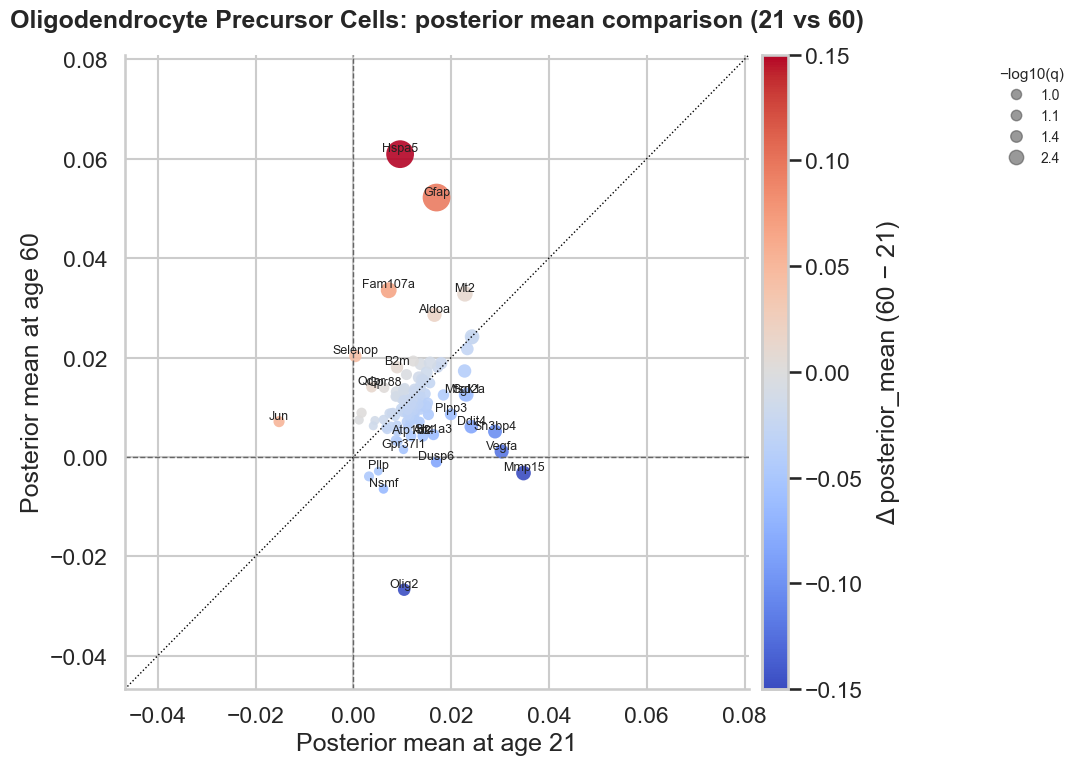

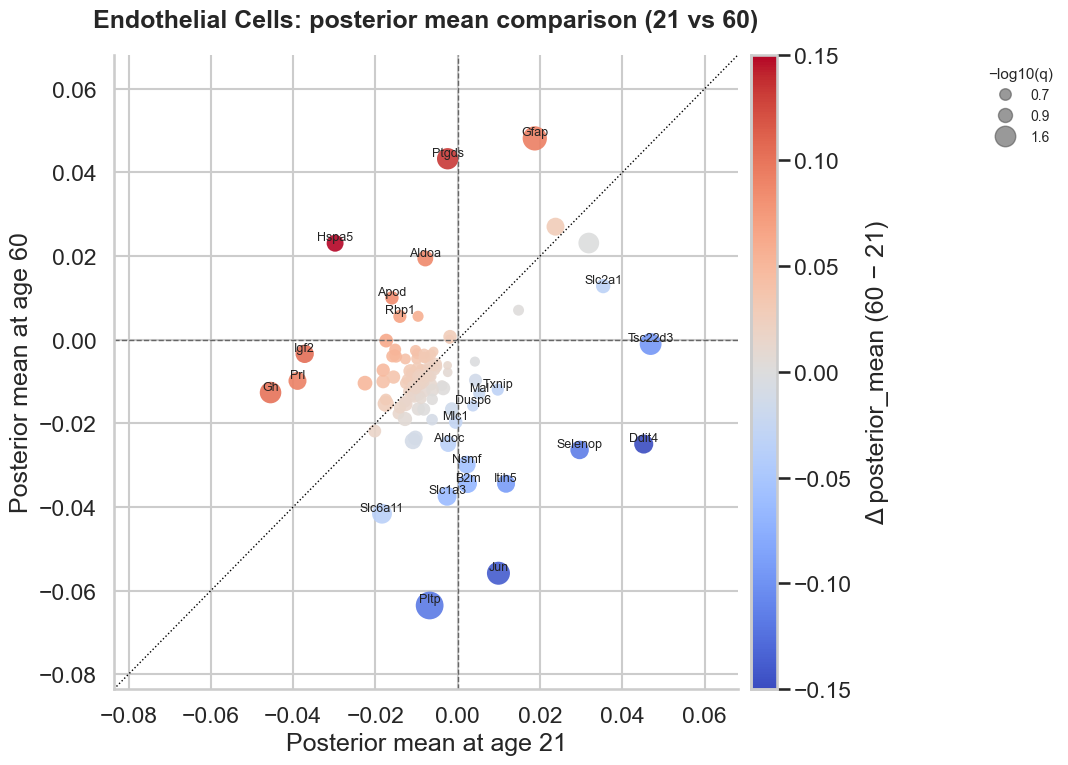

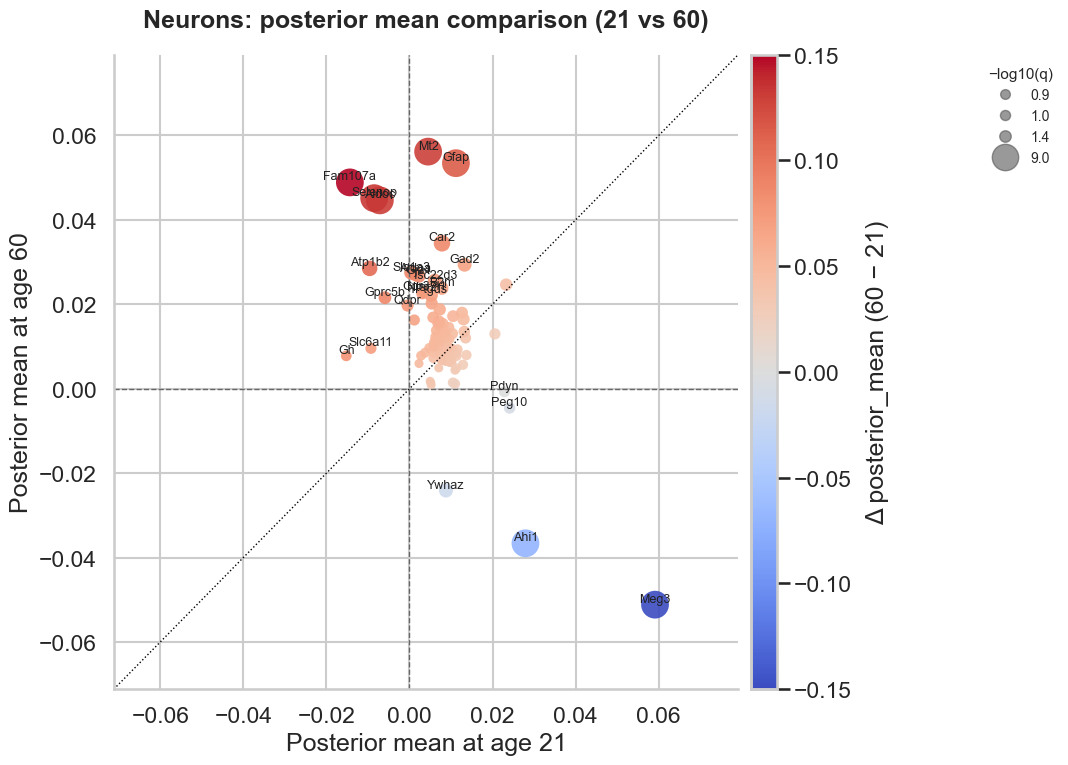

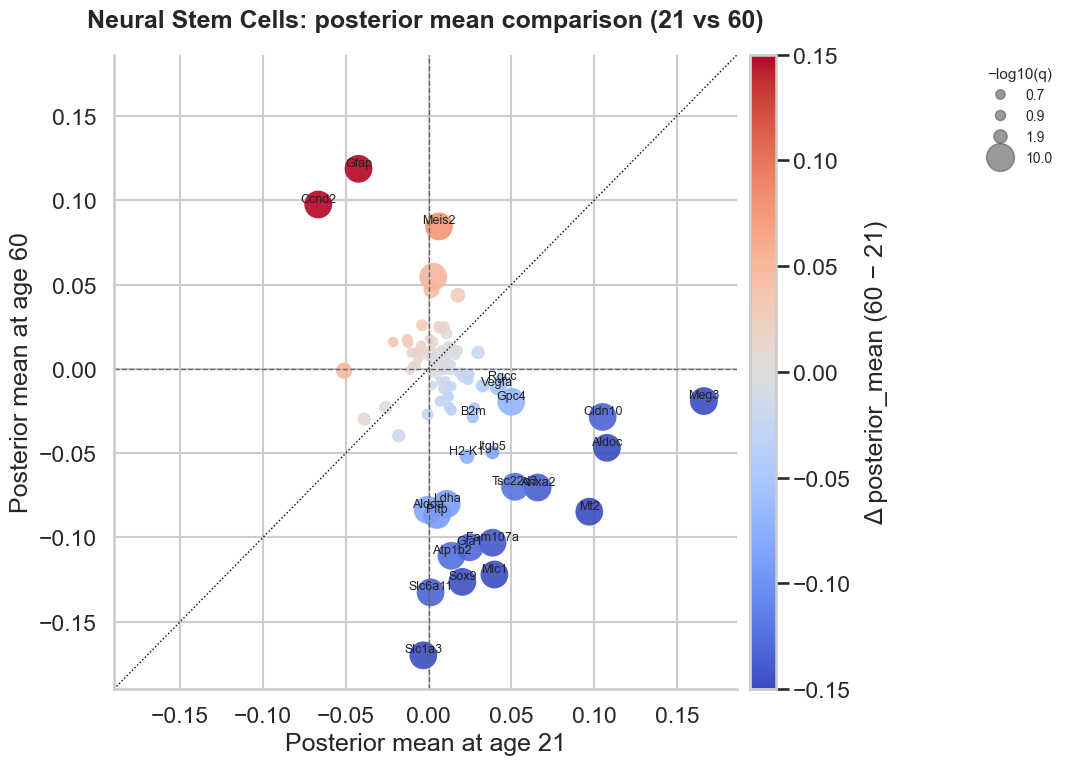

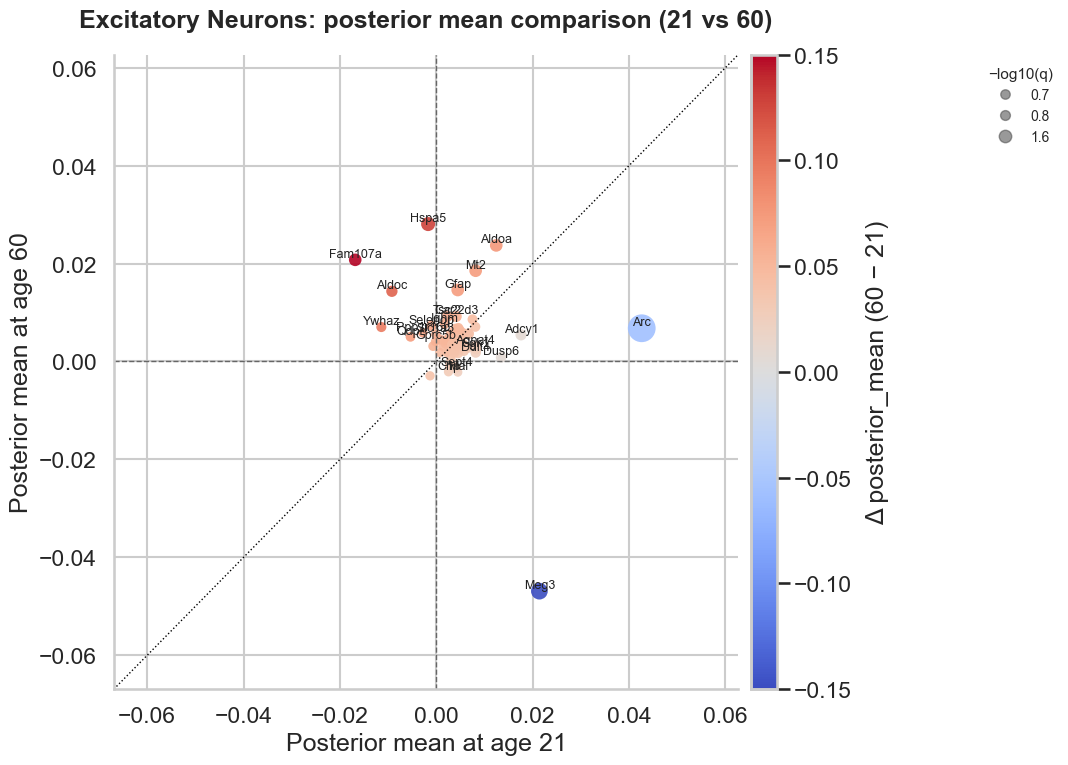

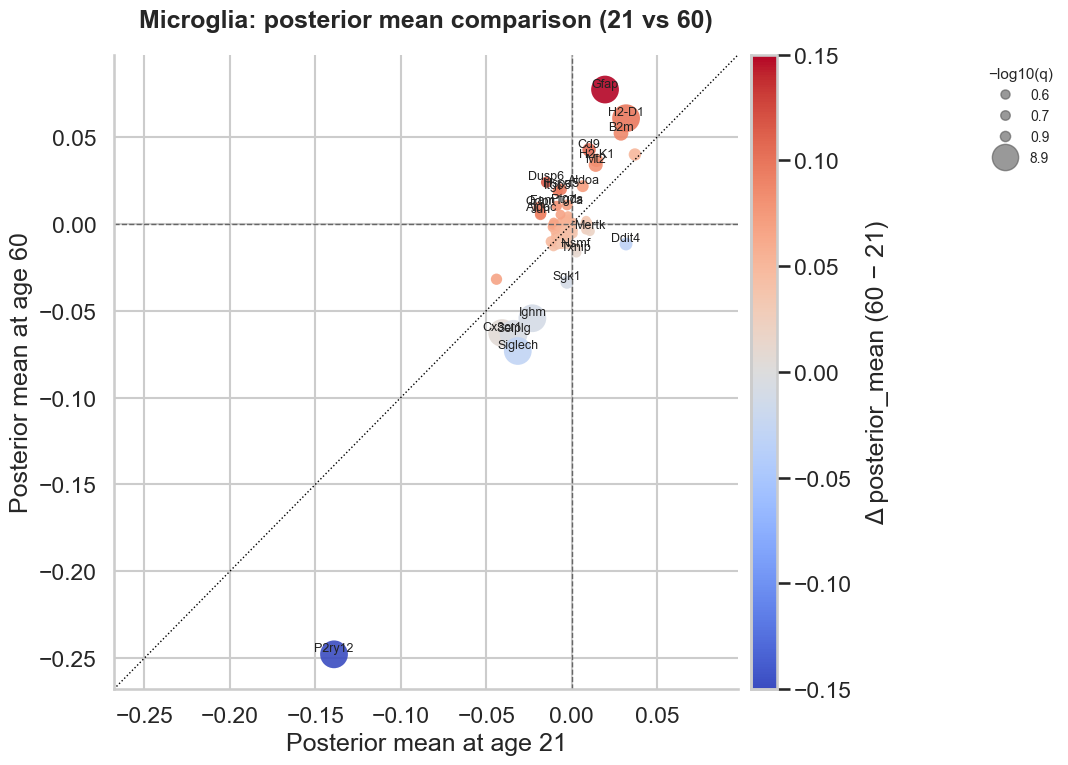

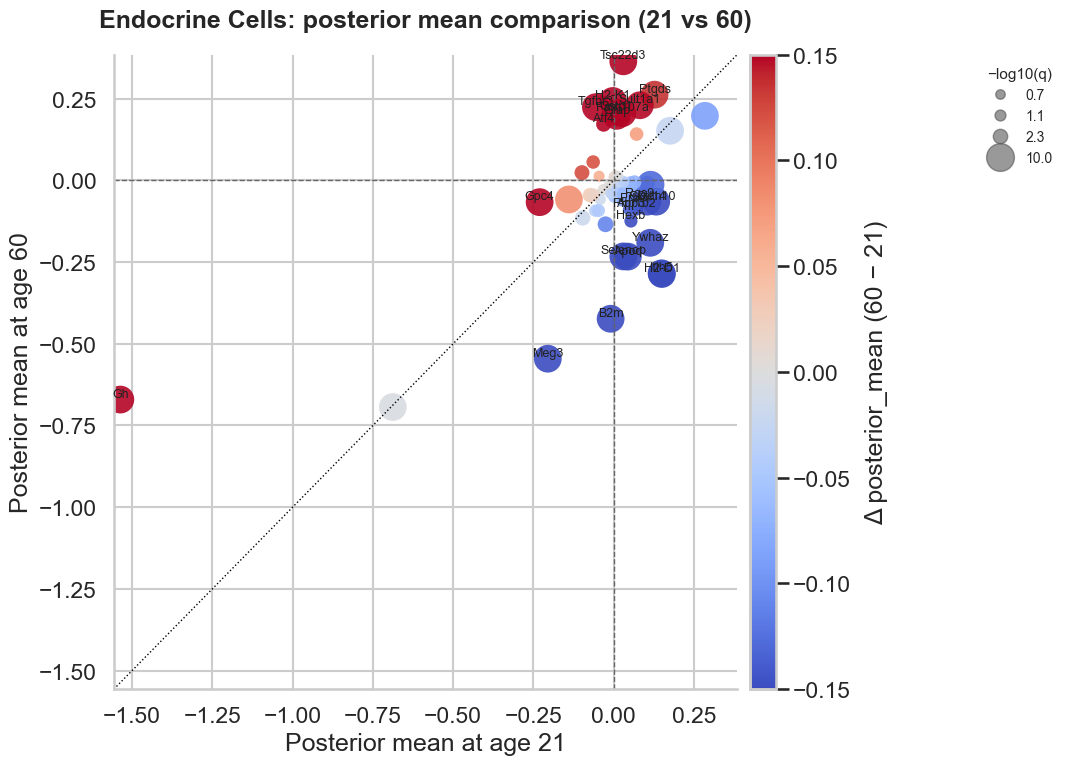

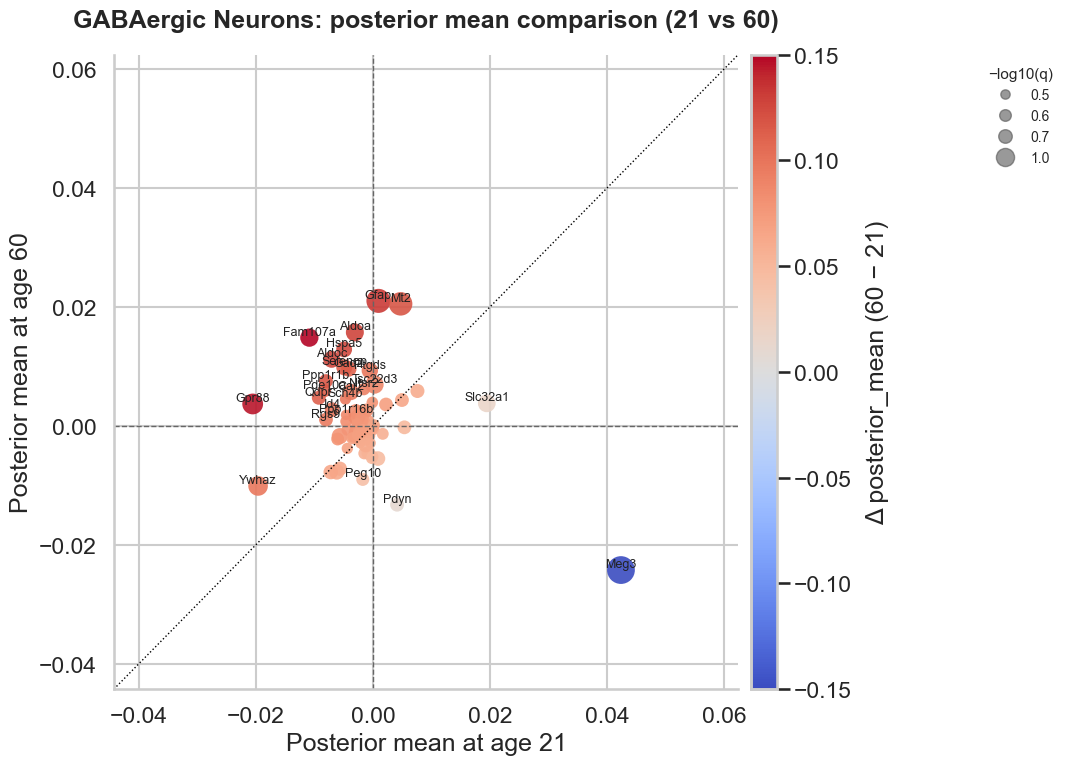

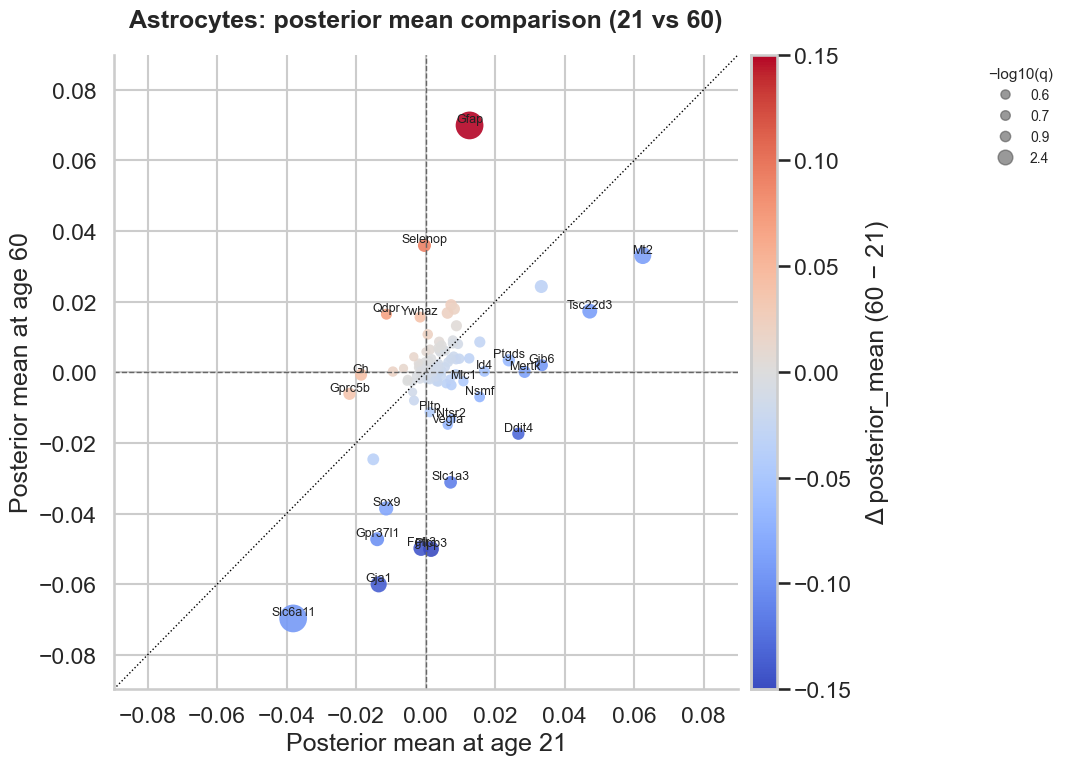

In [86]:
for celltype in cc.group.unique():
    if celltype == 'Oligodendrocytes':
        plot_bayesian_age_comparison(
            combined_df, celltype=celltype, age_x="21", age_y="60",
            force_genes=force_genes,
            remove_genes=["Xist"],              # gone from plot
            remove_from_labels_only=False
        )
    else: 
        plot_bayesian_age_comparison(
            combined_df, celltype=celltype, age_x="21", age_y="60",
#            force_genes=force_genes,
            remove_genes=["Xist",'Mbp'],              # gone from plot
            remove_from_labels_only=False
        )

In [87]:
import scanpy as sc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from matplotlib.lines import Line2D
from matplotlib import colors as mcolors
import warnings
warnings.filterwarnings("ignore")


def plot_spatial_compact_fast(
    ad,
    color="leiden_2",
    groupby="sample_id",
    spot_size=8,
    cols=3,
    height=8,
    legend_col_width=1.2,
    palette=None,            # dict {cat:"#hex"} or list
    rasterized=True,         # big speedup for vectors/PDFs
    invert_y=True,           # match Scanpy orientation
    dpi=120,                 # lower dpi → faster
):
    # ----- 0) Preconditions -----
    if "spatial" not in ad.obsm:
        raise ValueError("ad.obsm['spatial'] is required.")

    coords = np.asarray(ad.obsm["spatial"])[:, :2]
    cats = ad.obs[color].astype("category")
    cat_names = cats.cat.categories
    cat_codes = cats.cat.codes.to_numpy()  # -1 for NaN

    # ----- 1) Build shared palette (RGBA array) -----
    if isinstance(palette, dict):
        col_list = [palette[c] for c in cat_names]
    elif isinstance(palette, (list, tuple)):
        if len(palette) < len(cat_names):
            raise ValueError("Palette shorter than number of categories.")
        col_list = list(palette)[:len(cat_names)]
    elif f"{color}_colors" in ad.uns:
        col_list = list(ad.uns[f"{color}_colors"])
        if len(col_list) != len(cat_names):
            raise ValueError(f"{color}_colors length != categories.")
    else:
        base = getattr(getattr(__import__("scanpy").pl.palettes, "default_64", []), "__iter__", None)
        base = list(__import__("scanpy").pl.palettes.default_64
                    if hasattr(__import__("scanpy").pl.palettes, "default_64")
                    else __import__("scanpy").pl.palettes.default_102)
        reps = int(np.ceil(len(cat_names) / len(base)))
        col_list = (base * reps)[:len(cat_names)]

    # store for consistency elsewhere
    ad.uns[f"{color}_colors"] = col_list

    # convert to RGBA float array for fast indexing
    rgba = np.array([mcolors.to_rgba(c) for c in col_list], dtype=float)
    # map codes -> rgba; handle -1 (NaN) as transparent
    colors_arr = np.empty((cat_codes.size, 4), dtype=float)
    colors_arr[cat_codes >= 0] = rgba[cat_codes[cat_codes >= 0]]
    colors_arr[cat_codes < 0] = (0, 0, 0, 0)

    # ----- 2) Precompute group indices (no per-iteration masks) -----
    gvals = ad.obs[groupby].astype(str).to_numpy()
    uniq_groups, gcodes = np.unique(gvals, return_inverse=True)
    # list of index arrays per group
    group_indices = [np.flatnonzero(gcodes == gi) for gi in range(len(uniq_groups))]

    # ----- 3) Figure layout -----
    n = len(uniq_groups)
    rows = int(np.ceil(n / cols))
    panel_w = height * cols * 0.6 / rows
    fig_w = panel_w + legend_col_width

    plt.ioff()  # speed: disable interactive redraws
    fig = plt.figure(figsize=(fig_w, height), dpi=dpi, constrained_layout=False)
    gs = GridSpec(
        rows, cols + 1, figure=fig,
        width_ratios=[1]*cols + [legend_col_width / (fig_w - legend_col_width)],
        wspace=0.02, hspace=0.02
    )

    # ----- 4) Panels (fast scatter) -----
    for i, sid in enumerate(uniq_groups):
        r, c = divmod(i, cols)
        ax = fig.add_subplot(gs[r, c])

        idx = group_indices[i]
        if idx.size:
            xy = coords[idx]
            # note: turn off edgecolor & use rasterized for speed
            sca = ax.scatter(
                xy[:, 0], xy[:, 1],
                c=colors_arr[idx],
                s=spot_size,
                marker='o',
                linewidths=0,
                rasterized=rasterized
            )
        ax.set_title(str(sid), fontsize=9, pad=2)
        ax.set_aspect("equal")
        if invert_y:
            ax.invert_yaxis()
        ax.set_axis_off()

    # blank unused
    for j in range(n, rows * cols):
        r, c = divmod(j, cols)
        fig.add_subplot(gs[r, c]).axis("off")

    # ----- 5) Legend (single, shared) -----
    ax_leg = fig.add_subplot(gs[:, -1])
    ax_leg.axis("off")
    handles = [
        Line2D([0], [0], marker='o', color='w',
               markerfacecolor=col_list[k], markersize=7, label=str(cat))
        for k, cat in enumerate(cat_names)
    ]
    ax_leg.legend(handles=handles, title=color, frameon=False, loc="center left")

    fig.subplots_adjust(left=0.01, right=0.98, top=0.98, bottom=0.02, wspace=0.02, hspace=0.02)
    plt.ion()  # ✅ correct
    plt.show()

In [88]:
import scanpy as sc

In [89]:
adata = sc.read_h5ad('/Users/christoffer/work/karolinska/development/oligo-mtDSB/data/mtDNA_DSB_5k_clustered_annotation_with_rbd_2.h5ad')

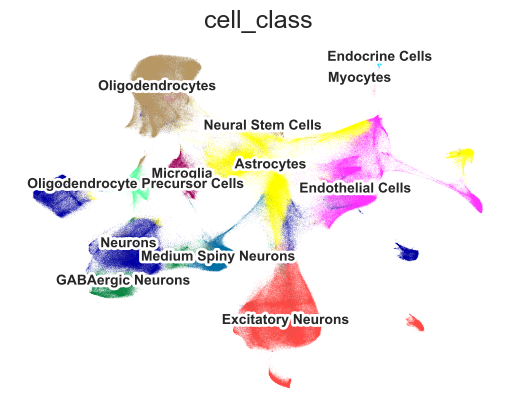

In [97]:
sc.pl.umap(adata, color = 'cell_class', legend_loc='on data', legend_fontsize = 10, frameon=False, legend_fontoutline=4)

Plotting cell_class …


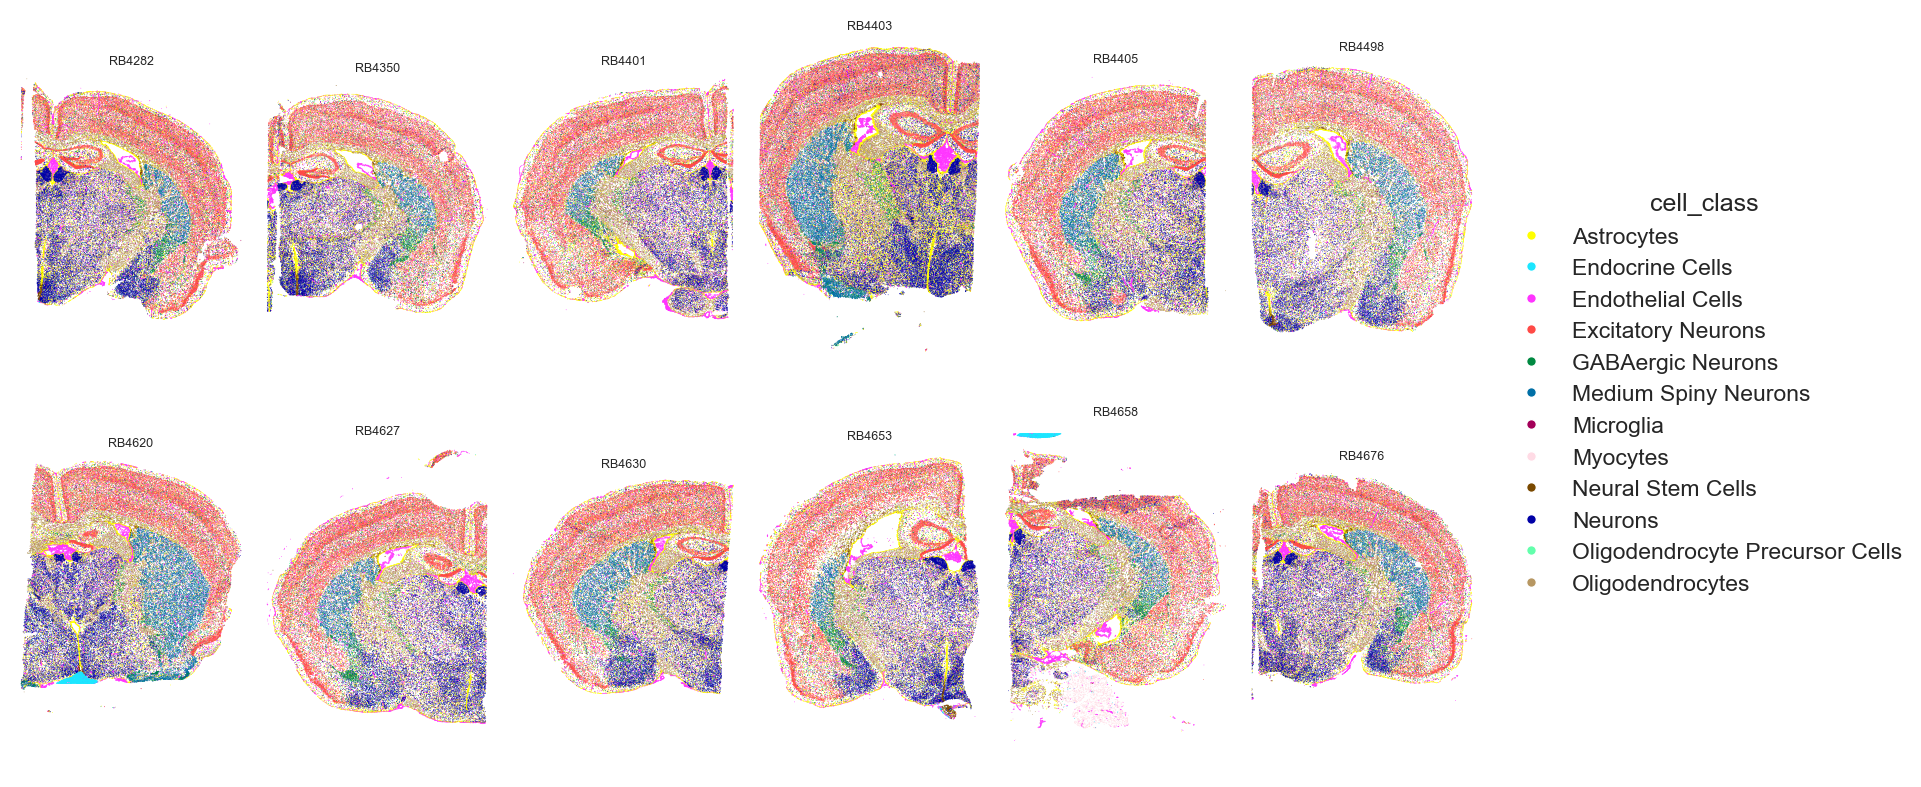

In [92]:
for domain in ['cell_class']:
    if domain in adata.obs.columns:
        print(f"Plotting {domain} …")
        plot_spatial_compact_fast(
            adata,
            color=domain,
            groupby="sample_id",
            spot_size=0.3,
            cols=6,
            height=8,
            legend_col_width=1.0,
            rasterized=True,   # big speedup for large data
            dpi=100             # lower = faster preview
        )
    else:
        print(f"Skipping {domain} — not in adata.obs")

In [98]:
import scanpy as sc
import numpy as np
import matplotlib.pyplot as plt
import scanpy as sc
from matplotlib.lines import Line2D
from matplotlib.gridspec import GridSpec

def plot_spatial_compact(
    ad,
    color="leiden_2",
    groupby="sample_id",
    spot_size=18,
    cols=3,
    height=8,
    legend_col_width=1.2,
    palette=None,          # <- NEW: dict {category: "#hex"} or list in desired order
):
    # --- categories from the FULL object (freeze order) ---
    cats = ad.obs[color].astype("category").cat.categories

    # --- build a shared color list in that order ---
    if isinstance(palette, dict):
        cols_list = [palette[c] for c in cats]
    elif isinstance(palette, (list, tuple)):
        if len(palette) < len(cats):
            raise ValueError("Palette list shorter than number of categories.")
        cols_list = list(palette)[:len(cats)]
    elif f"{color}_colors" in ad.uns:
        # reuse existing palette if present on the full object
        cols_list = list(ad.uns[f"{color}_colors"])
        if len(cols_list) != len(cats):
            raise ValueError(f"{color}_colors length does not match categories.")
    else:
        base = sc.pl.palettes.default_64 if hasattr(sc.pl.palettes, "default_64") else sc.pl.palettes.default_102
        reps = int(np.ceil(len(cats) / len(base)))
        cols_list = (base * reps)[:len(cats)]

    # store on the full object too (handy if you plot elsewhere later)
    ad.uns[f"{color}_colors"] = cols_list

    # --- layout ---
    sids = list(ad.obs[groupby].unique())
    n = len(sids)
    rows = int(np.ceil(n / cols))

    panel_w = height * cols * 0.6 / rows
    fig_w = panel_w + legend_col_width
    fig = plt.figure(figsize=(fig_w, height), constrained_layout=False)

    gs = GridSpec(
        rows, cols + 1, figure=fig,
        width_ratios=[1]*cols + [legend_col_width / (fig_w - legend_col_width)],
        wspace=0.02, hspace=0.02
    )

    # --- panels ---
    for i, sid in enumerate(sids):
        r, c = divmod(i, cols)
        ax = fig.add_subplot(gs[r, c])

        ad_sub = ad[ad.obs[groupby] == sid].copy()

        # CRUCIAL: force identical categories & palette on each subset
        ad_sub.obs[color] = ad_sub.obs[color].astype("category")
        ad_sub.obs[color] = ad_sub.obs[color].cat.set_categories(cats)
        ad_sub.uns[f"{color}_colors"] = cols_list

        sc.pl.spatial(
            ad_sub, color=color, spot_size=spot_size,
            show=False, ax=ax, legend_loc=None, frameon=False, title=str(sid)
        )
        ax.set_xlabel(""); ax.set_ylabel("")
        ax.tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)

    # blank unused
    for j in range(n, rows*cols):
        r, c = divmod(j, cols)
        fig.add_subplot(gs[r, c]).axis("off")

    # --- legend ---
    ax_leg = fig.add_subplot(gs[:, -1])
    ax_leg.axis("off")
    handles = [
        Line2D([0], [0], marker='o', color='w',
               markerfacecolor=cols_list[k], markersize=7, label=str(cat))
        for k, cat in enumerate(cats)
    ]
    ax_leg.legend(handles=handles, title=color, frameon=False, loc="center left")

    fig.subplots_adjust(left=0.01, right=0.98, top=0.98, bottom=0.02, wspace=0.02, hspace=0.02)
    plt.show()

import numpy as np
import matplotlib.pyplot as plt
import scanpy as sc
from matplotlib.gridspec import GridSpec
from matplotlib.colors import Normalize

def plot_spatial_genes_compact(
    ad,
    genes,
    groupby="sample_id",
    spot_size=18,
    cols=3,
    height=8,
    cmap="magma",          # any matplotlib colormap
    log1p=False,           # log1p-transform before plotting
    robust=True,           # use robust 2–98% limits instead of min/max
    vmin=None, vmax=None,  # override global color limits if you want
    nan_color="lightgray", # background for zero/NaN
    title_suffix="",
):
    """
    Plot per-sample spatial maps for one or multiple genes (continuous).
    Uses a shared color scale across all samples for each gene.
    """

    # ensure genes is a list
    genes = [genes] if isinstance(genes, str) else list(genes)
    sids  = list(ad.obs[groupby].unique())
    nS, nG = len(sids), len(genes)

    # grid: rows = samples, cols = genes + 1 legend column
    cols_total = nG + 1
    rows = int(np.ceil(nS))
    fig = plt.figure(figsize=(height * cols_total * 0.6, height), constrained_layout=False)
    gs  = GridSpec(rows, cols_total, figure=fig, width_ratios=[1]*nG + [0.25],
                   wspace=0.03, hspace=0.03)

    for gi, g in enumerate(genes):
        if g not in ad.var_names:
            print(f"⚠️ Gene '{g}' not in var_names; skipping.")
            continue

        # collect values across ALL samples to set shared limits
        vals = ad[:, g].X
        vals = vals.toarray().ravel() if hasattr(vals, "toarray") else np.asarray(vals).ravel()
        if log1p: vals = np.log1p(vals)

        if vmin is None or vmax is None:
            if robust:
                lo, hi = np.nanpercentile(vals, [2, 98])
            else:
                lo, hi = np.nanmin(vals), np.nanmax(vals)
        else:
            lo, hi = vmin, vmax
        if hi <= lo:  # degenerate case
            hi = lo + 1e-9
        norm = Normalize(vmin=lo, vmax=hi)

        # draw per-sample panels for this gene
        for si, sid in enumerate(sids):
            ax = fig.add_subplot(gs[si, gi]) if rows > 1 else fig.add_subplot(gs[0, gi])
            ad_sub = ad[ad.obs[groupby] == sid].copy()

            # precompute color values so Scanpy respects global norm
            v = ad_sub[:, g].X
            v = v.toarray().ravel() if hasattr(v, "toarray") else np.asarray(v).ravel()
            if log1p: v = np.log1p(v)
            # map to colors
            cmap_obj = plt.get_cmap(cmap)
            rgba = cmap_obj(norm(v))
            # make zeros / NaNs pale
            mask = ~np.isfinite(v) | (v <= 0)
            rgba[mask, :3] = plt.matplotlib.colors.to_rgb(nan_color)  # set color
            rgba[mask, 3]  = 1.0                                     # opaque

            # Scanpy trick: provide precomputed colors via obs (as hex)
            import matplotlib.colors as mcolors
            hex_colors = [mcolors.to_hex(c) for c in rgba]
            ad_sub.obs[f"__{g}__colors"] = hex_colors

            sc.pl.spatial(
                ad_sub,
                color=f"__{g}__colors",           # plot with our precomputed colors
                spot_size=spot_size,
                show=False,
                ax=ax,
                title=f"{sid}" + (f" • {title_suffix}" if title_suffix else ""),
                frameon=False,
                legend_loc=None,
            )
            ax.set_xlabel(""); ax.set_ylabel("")
            ax.tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)

        # add a colorbar column only once per gene
        cb_ax = fig.add_subplot(gs[:, -1]) if rows > 1 else fig.add_subplot(gs[0, -1])
        if gi == nG - 1:  # only draw once (last gene) to avoid redraw
            cb_ax.axis("off")
            sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
            sm.set_array([])
            cbar = fig.colorbar(sm, ax=cb_ax, fraction=0.8)
            cbar.set_label(f"{'log1p(' if log1p else ''}{genes[-1]}{')' if log1p else ''}", rotation=90)

    fig.subplots_adjust(left=0.02, right=0.98, top=0.96, bottom=0.02, wspace=0.02, hspace=0.02)
    plt.show()


def plot_spatial_any(
    ad,
    feature,
    **kwargs
):
    """
    Convenience dispatcher:
      - If `feature` is a column in .obs (categorical), call plot_spatial_compact
      - If `feature` is a gene (in .var_names), call plot_spatial_genes_compact
    """
    if feature in ad.obs.columns and pd.api.types.is_categorical_dtype(ad.obs[feature]):
        return plot_spatial_compact(ad, color=feature, **kwargs)
    elif feature in ad.var_names:
        return plot_spatial_genes_compact(ad, genes=feature, **kwargs)
    else:
        raise ValueError(f"'{feature}' not found as categorical obs or gene.")

import matplotlib.pyplot as plt
import scanpy as sc
import numpy as np

def plot_spatial_highlight(
    ad,
    color="rbd_domain_0.5",
    highlight=None,            # one or multiple categories to highlight
    groupby="sample_id",
    spot_size=18,
    cols=3,
    height=8,
    base_color="lightgrey",
    highlight_color=None,      # auto from palette if None
):
    """
    Plot one or several clusters highlighted in color, others grey.
    """

    if highlight is None:
        raise ValueError("Please specify at least one value in `highlight`")

    # make a copy to avoid modifying original
    ad = ad.copy()
    vals = ad.obs[color].astype(str)

    # identify highlight set
    highlight = [highlight] if isinstance(highlight, str) else list(highlight)
    mask = vals.isin(highlight)

    # define colors
    # reuse existing palette if present
    if f"{color}_colors" in ad.uns:
        pal = dict(zip(ad.obs[color].cat.categories, ad.uns[f"{color}_colors"]))
    else:
        base = getattr(sc.pl.palettes, "default_102", sc.pl.palettes.vega_20)
        cats = ad.obs[color].astype("category").cat.categories
        reps = int(np.ceil(len(cats)/len(base)))
        all_colors = (base * reps)[:len(cats)]
        pal = dict(zip(cats, all_colors))

    # pick one highlight color (first of list)
    if highlight_color is None:
        highlight_color = pal.get(highlight[0], "#d62728")  # fallback red

    # new column for plotting
    ad.obs["_highlight_plot_"] = np.where(mask, highlight[0], "other")
    ad.obs["_highlight_plot_"] = ad.obs["_highlight_plot_"].astype("category")

    # define palette for two classes: highlighted + grey
    palette = {"other": base_color, highlight[0]: highlight_color}

    # use your existing compact plot function
    plot_spatial_compact(
        ad,
        color="_highlight_plot_",
        groupby=groupby,
        spot_size=spot_size,
        cols=cols,
        height=height,
        palette=palette
    )

import numpy as np
import os
import matplotlib.pyplot as plt
import scanpy as sc

def _flip_y_inplace(ad):
    """Flip Y in .obsm['spatial'] so 'up' is up."""
    XY = ad.obsm["spatial"].copy()
    XY[:, 1] = XY[:, 1].max() - XY[:, 1]
    ad.obsm["spatial"] = XY
    return ad

def plot_spatial_highlight(
    adata,
    color="rbd_domain_0.5",
    highlight=None,
    groupby="sample_id",
    spot_size=18,
    cols=3,
    height=7,
    grey="#D9D9D9",
    cmap_highlight=None,
    flip_y=True,          # <- NEW: flip coordinates, not axes
    fix_limits=True       # <- NEW: keep consistent x/y limits across panels
):
    assert highlight is not None, "Provide a `highlight` category to emphasize."
    cats = adata.obs[color].astype("category").cat.categories
    sids = list(adata.obs[groupby].unique())
    n, rows = len(sids), int(np.ceil(len(sids)/cols))

    # choose highlight color
    if cmap_highlight is None and f"{color}_colors" in adata.uns and highlight in cats:
        hl_col = adata.uns[f"{color}_colors"][list(cats).index(highlight)]
    else:
        hl_col = cmap_highlight or "#3949ab"

    # global limits (after potential flip) so all axes are identical
    if fix_limits:
        ad_tmp = adata.copy()
        if flip_y: _flip_y_inplace(ad_tmp)
        X, Y = ad_tmp.obsm["spatial"][:,0], ad_tmp.obsm["spatial"][:,1]
        xlim = (X.min(), X.max())
        ylim = (Y.min(), Y.max())
        del ad_tmp
    else:
        xlim = ylim = None

    fig_w = cols * (height * 0.7); fig_h = height
    fig, axs = plt.subplots(rows, cols, figsize=(fig_w, fig_h), squeeze=False)
    for ax in axs.flat: ax.set_axis_off()

    for i, sid in enumerate(sids):
        r, c = divmod(i, cols)
        ax = axs[r, c]
        ad_sub = adata[adata.obs[groupby] == sid].copy()
        if flip_y: _flip_y_inplace(ad_sub)

        # masks
        mask_hi = (ad_sub.obs[color] == highlight)
        mask_lo = ~mask_hi

        # background (grey)
        if mask_lo.sum():
            sc.pl.spatial(ad_sub[mask_lo], color=None, spot_size=spot_size,
                          show=False, ax=ax, frameon=False)
            coll = ax.collections[-1]
            coll.set_facecolor(grey); coll.set_edgecolor("none")

        # highlight (colored)
        if mask_hi.sum():
            plt.rcParams["scatter.marker"] = "."
            plt.rcParams["patch.linewidth"] = 0

            sc.pl.spatial(ad_sub[mask_hi], color=None, spot_size=spot_size,
                          show=False, ax=ax, frameon=False)
            coll = ax.collections[-1]
            coll.set_facecolor(hl_col); coll.set_edgecolor("none")

        # lock limits so panels align
        if xlim: ax.set_xlim(*xlim)
        if ylim: ax.set_ylim(*ylim)

        ax.set_title(f"{sid} • {color}={highlight}", fontsize=10)

    # blank unused
    for j in range(n, rows*cols):
        r, c = divmod(j, cols)
        axs[r, c].axis("off")

    plt.tight_layout()
    return fig, axs



In [100]:
adata.obs

,x_centroid,y_centroid,transcript_counts,control_probe_counts,genomic_control_counts,control_codeword_counts,unassigned_codeword_counts,deprecated_codeword_counts,total_counts,cell_area,...,rbd_domain_0.2,rbd_domain_0.5,rbd_domain_1.0,RBD_compartment,RBD_compartment_simplified,leiden_1.5,leiden_2.1,leiden_2.3,leiden_2.5,leiden_3
aaaaakjg-1,67.136543,1092.286377,631,0,0,0,1,0,631.0,37.434533,...,0,0,5,Cortex III,Cortex,21,27,25,27,29
aaaaikjn-1,80.635910,779.488647,1102,0,0,0,2,0,1102.0,90.538285,...,0,0,38,Unknown III,Unknown,3,29,27,32,30
aaaapoln-1,67.554489,1513.168579,335,0,0,0,0,0,335.0,20.817032,...,0,0,4,Cortex II,Cortex,9,14,13,10,10
aaacmkgf-1,70.575630,1138.702881,1931,0,0,0,1,0,1931.0,81.055472,...,0,0,5,Cortex III,Cortex,9,29,27,32,30
aaaefdnf-1,583.425537,1142.197876,1105,0,0,0,1,0,1105.0,68.276252,...,0,0,5,Cortex III,Cortex,17,17,22,17,17
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
oifndkbo-1,2379.717529,4785.681152,419,0,0,0,0,0,419.0,42.221095,...,1,2,0,Hypothalamus,Hypothalamus,4,21,37,42,45
oifolalk-1,2281.881104,4803.725098,219,0,0,0,0,0,219.0,36.170158,...,1,2,0,Hypothalamus,Hypothalamus,19,11,15,19,40
oifphdni-1,2343.403564,4830.252441,76,0,0,0,0,0,76.0,14.946719,...,1,2,0,Hypothalamus,Hypothalamus,4,21,37,38,33
oigabhlk-1,2341.813477,4843.651367,176,0,0,0,0,0,176.0,30.661095,...,1,2,0,Hypothalamus,Hypothalamus,19,11,15,19,40


Plotting RBD_compartment_simplified …


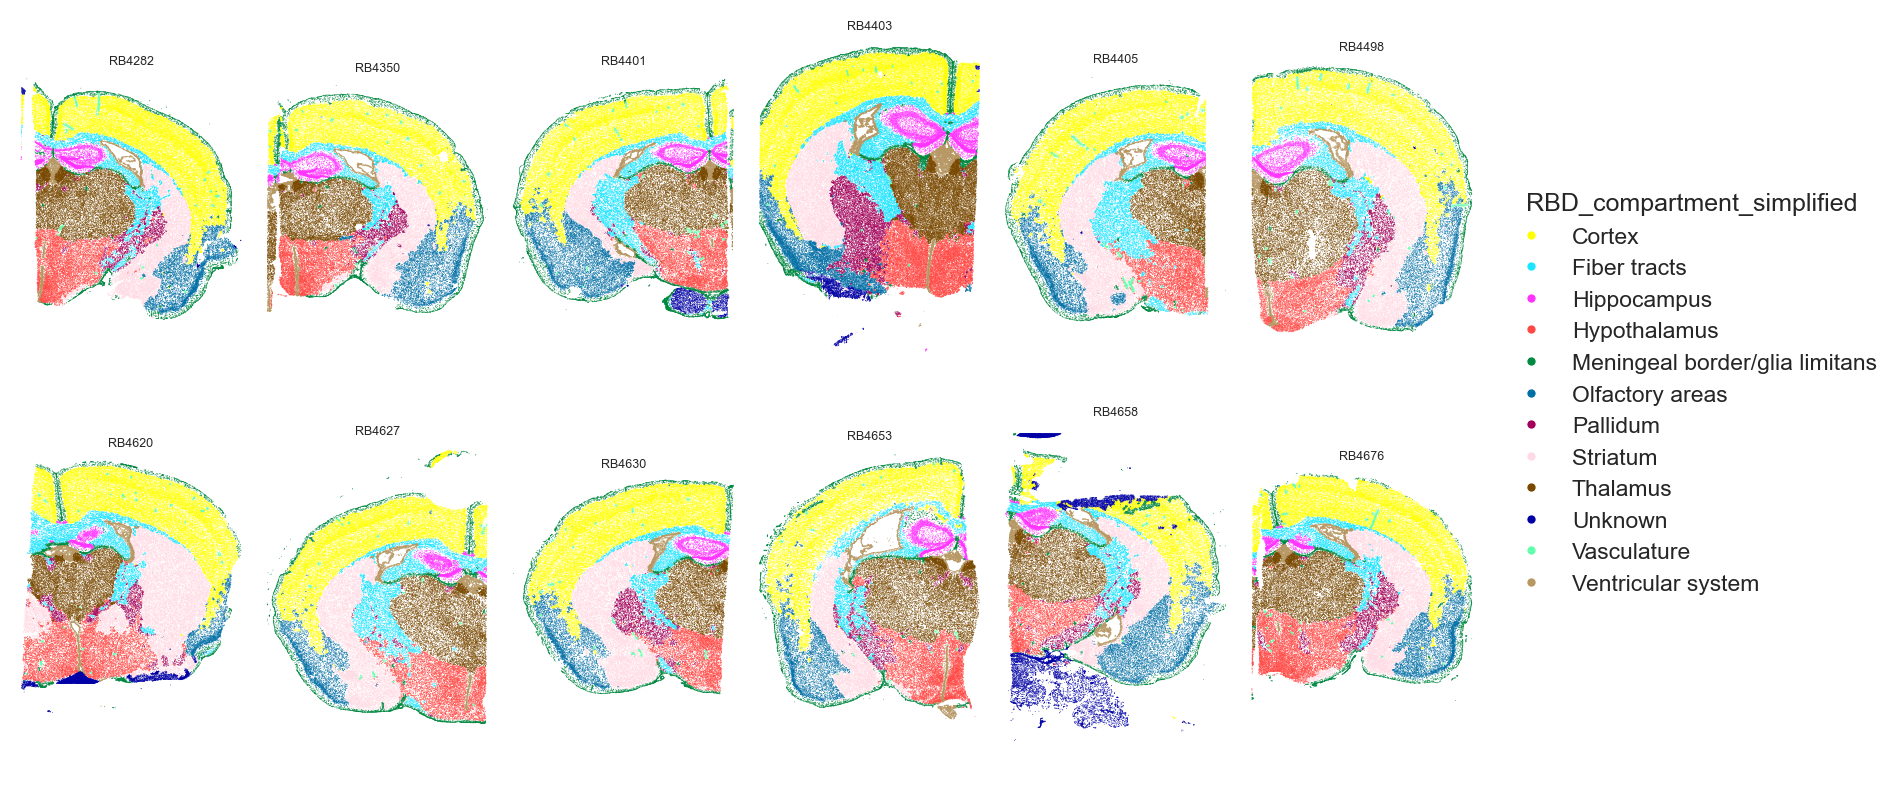

In [102]:
for domain in ['RBD_compartment_simplified']:
    if domain in adata.obs.columns:
        print(f"Plotting {domain} …")
        plot_spatial_compact_fast(
            adata,
            color=domain,
            groupby="sample_id",
            spot_size=0.3,
            cols=6,
            height=8,
            legend_col_width=1.0,
            rasterized=True,   # big speedup for large data
            dpi=100             # lower = faster preview
        )
    else:
        print(f"Skipping {domain} — not in adata.obs")

In [106]:
outdir = "../results/compartments_all"
os.makedirs(outdir)

In [108]:
cl

'Meningeal border/glia limitans'

In [ ]:
import os
import matplotlib.pyplot as plt

domain_key = "RBD_compartment_simplified"
os.makedirs(outdir, exist_ok=True)

for cl in adata.obs[domain_key].astype("category").cat.categories:
    # handle special case name
    cl_name = "meninges" if cl == "Meningeal border/glia limitans" else cl
    outpath = os.path.join(outdir, f"{domain_key}_cluster_{cl_name}.png")

    # skip if file already exists
    if os.path.exists(outpath):
        print(f"⏭️ Skipping {cl_name} — already saved at {outpath}")
        continue

    # generate plot
    print(f"🖼️ Generating {cl_name}...")
    fig, _ = plot_spatial_highlight(
        adata, color=domain_key, highlight=cl,
        groupby="sample_id", spot_size=20, cols=6, height=8,
        flip_y=True, fix_limits=True
    )

    # save plot
    fig.savefig(outpath, dpi=300, bbox_inches="tight")
    plt.close(fig)
    print(f"✅ Saved → {outpath}")

⏭️ Skipping Cortex — already saved at ../results/compartments_all/RBD_compartment_simplified_cluster_Cortex.png
⏭️ Skipping Fiber tracts — already saved at ../results/compartments_all/RBD_compartment_simplified_cluster_Fiber tracts.png
⏭️ Skipping Hippocampus — already saved at ../results/compartments_all/RBD_compartment_simplified_cluster_Hippocampus.png
⏭️ Skipping Hypothalamus — already saved at ../results/compartments_all/RBD_compartment_simplified_cluster_Hypothalamus.png
🖼️ Generating meninges...
